# Corrective RAG (CRAG) — LangChain LCEL + Gemini

Implements the architecture from the CRAG paper (Yan et al.) using LCEL:

1. **Retrieval** — vector store retrieves candidate docs for query `x`
2. **Knowledge Correction**
   - **Retrieval Evaluator** grades each doc as `Correct` / `Ambiguous` / `Incorrect`
   - **Knowledge Refinement** (Correct/Ambiguous): decompose → strip filter → recompose → `k_in`
   - **Knowledge Searching** (Ambiguous/Incorrect): rewrite query → web search → select → `k_ex`
3. **Generation** — `x + k_in`, `x + k_in + k_ex`, or `x + k_ex` depending on branch

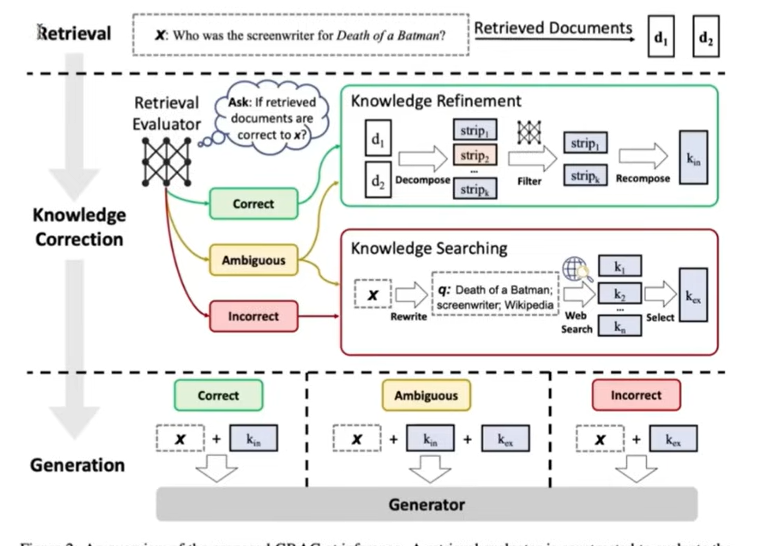

In [37]:
import os
import getpass
from typing import List, Literal

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnableBranch, RunnablePassthrough
from pydantic import BaseModel, Field

from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.tools import DuckDuckGoSearchResults

from dotenv import load_dotenv
load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

## 1. Retrieval

Small in-memory corpus, some relevant, some irrelevant/noisy, to actually exercise all three branches.

In [38]:
docs = [
    Document(page_content=(
        "Death of a Batman is a 2023 fan film written and directed by "
        "Marcus Reyes, produced independently and released on YouTube."
    )),
    Document(page_content=(
        "The screenplay for Death of a Batman went through three drafts, "
        "with Marcus Reyes credited as sole screenwriter."
    )),
    Document(page_content=(
        "Batman is a fictional superhero created by Bob Kane and Bill Finger, "
        "first appearing in Detective Comics #27 in 1939."
    )),
    Document(page_content=(
        "The Death of Superman is a 1992 comic book storyline published by DC Comics."
    )),
]

vectorstore = FAISS.from_documents(docs, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

retriever.invoke("Who was the screenwriter for Death of a Batman?")

[Document(id='605ab81c-d5bd-47f8-adbd-7e27d85cbc1a', metadata={}, page_content='The screenplay for Death of a Batman went through three drafts, with Marcus Reyes credited as sole screenwriter.'),
 Document(id='a5f9509b-a1ee-42a9-9f93-0ae7c2800ec6', metadata={}, page_content='Death of a Batman is a 2023 fan film written and directed by Marcus Reyes, produced independently and released on YouTube.'),
 Document(id='93a3237e-4b92-4ee9-966a-da53fdf11bec', metadata={}, page_content='Batman is a fictional superhero created by Bob Kane and Bill Finger, first appearing in Detective Comics #27 in 1939.'),
 Document(id='475b4da9-0c5e-4924-a612-801b9b70c678', metadata={}, page_content='The Death of Superman is a 1992 comic book storyline published by DC Comics.')]

## 2. Retrieval Evaluator

Grades each retrieved doc's relevance to `x` on 0-1. CRAG uses upper/lower thresholds on the
best-scoring doc to decide the overall action:

- `score >= upper` → **Correct**
- `score <= lower` → **Incorrect**
- otherwise → **Ambiguous**

In [39]:
class RelevanceGrade(BaseModel):
    score: float = Field(description="Relevance of the document to the question, 0.0 to 1.0")
    reasoning: str = Field(description="One short sentence justifying the score")


grader_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a strict retrieval evaluator. Score how relevant the document is to answering "
     "the question, from 0.0 (irrelevant) to 1.0 (directly answers it)."),
    ("human", "Question: {question}\n\nDocument:\n{document}"),
])

# usually here we can use a finetuned model or a simple model to do the grading, but for this example we will use a general LLM
grader_chain = grader_prompt | llm.with_structured_output(RelevanceGrade)

UPPER_THRESHOLD = 0.7
LOWER_THRESHOLD = 0.3


def evaluate_retrieval(inputs: dict) -> dict:
    question, docs = inputs["question"], inputs["documents"]
    graded = []
    for doc in docs:
        grade = grader_chain.invoke({"question": question, "document": doc.page_content})
        graded.append({"document": doc, "score": grade.score})

    graded.sort(key=lambda d: d["score"], reverse=True)
    best_score = graded[0]["score"] if graded else 0.0

    if best_score >= UPPER_THRESHOLD:
        action = "Correct"
    elif best_score <= LOWER_THRESHOLD:
        action = "Incorrect"
    else:
        action = "Ambiguous"

    return {"question": question, "graded_documents": graded, "action": action}


evaluator = RunnableLambda(evaluate_retrieval)

## 3. Knowledge Refinement (Correct / Ambiguous branch)

Decompose each relevant doc into strips (sentences) → filter irrelevant strips → recompose into `k_in`.

In [40]:
import re


class StripRelevance(BaseModel):
    relevant: bool = Field(description="Whether this strip is relevant to the question")


strip_grader_prompt = ChatPromptTemplate.from_messages([
    ("system", "Decide if this single sentence is relevant to answering the question."),
    ("human", "Question: {question}\n\nSentence: {strip}"),
])
strip_grader_chain = strip_grader_prompt | llm.with_structured_output(StripRelevance)


def decompose(text: str) -> List[str]:
    strips = re.split(r"(?<=[.!?])\s+", text.strip())
    return [s for s in strips if s]


def knowledge_refinement(inputs: dict) -> str:
    question = inputs["question"]
    graded_documents = inputs["graded_documents"]

    # Only refine documents that cleared the lower threshold
    relevant_docs = [g["document"] for g in graded_documents if g["score"] > LOWER_THRESHOLD]

    kept_strips = []
    for doc in relevant_docs:
        for strip in decompose(doc.page_content):
            verdict = strip_grader_chain.invoke({"question": question, "strip": strip})
            if verdict.relevant:
                kept_strips.append(strip)

    return " ".join(kept_strips)  # recompose -> k_in


refine_knowledge = RunnableLambda(knowledge_refinement)

## 4. Knowledge Searching (Ambiguous / Incorrect branch)

Rewrite the question into search-engine-style keywords → web search → select top snippets → `k_ex`.

In [41]:
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Rewrite the question into a short web search query of keywords only, "
     "the way you'd type into a search engine. No punctuation, no explanation."),
    ("human", "{question}"),
])
rewrite_chain = rewrite_prompt | llm | StrOutputParser()

search_tool = DuckDuckGoSearchResults(output_format="list")  # list of {title, link, snippet}


def knowledge_searching(inputs: dict) -> str:
    question = inputs["question"]

    # 1. Rewrite: question -> search-engine-style query
    query = rewrite_chain.invoke({"question": question}).strip()

    # 2. Web search
    results = search_tool.invoke(query)

    # 3. Select: decompose each result into strips, filter, recompose
    #    (reuses decompose() and strip_grader_chain from Knowledge Refinement)
    kept_strips = []
    for r in results:
        snippet = r.get("snippet", "") if isinstance(r, dict) else str(r)
        for strip in decompose(snippet):
            verdict = strip_grader_chain.invoke({"question": question, "strip": strip})
            if verdict.relevant:
                kept_strips.append(strip)

    return " ".join(kept_strips)  # k_ex


search_knowledge = RunnableLambda(knowledge_searching)

## 5. Knowledge Correction orchestrator

Routes the evaluator output to refinement, search, or both, exactly matching the three
columns in the diagram: `Correct → k_in`, `Ambiguous → k_in + k_ex`, `Incorrect → k_ex`.

In [42]:
def correct_branch(inputs: dict) -> dict:
    k_in = refine_knowledge.invoke(inputs)
    return {"question": inputs["question"], "k_in": k_in, "k_ex": ""}


def ambiguous_branch(inputs: dict) -> dict:
    k_in = refine_knowledge.invoke(inputs)
    k_ex = search_knowledge.invoke(inputs)
    return {"question": inputs["question"], "k_in": k_in, "k_ex": k_ex}


def incorrect_branch(inputs: dict) -> dict:
    k_ex = search_knowledge.invoke(inputs)
    return {"question": inputs["question"], "k_in": "", "k_ex": k_ex}


knowledge_correction = RunnableBranch(
    (lambda x: x["action"] == "Correct", RunnableLambda(correct_branch)),
    (lambda x: x["action"] == "Incorrect", RunnableLambda(incorrect_branch)),
    RunnableLambda(ambiguous_branch),  # default = Ambiguous
)

## 6. Generation

Combines `x` with whichever knowledge was produced (`k_in`, `k_ex`, or both).

In [43]:
generation_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Answer the question using only the provided knowledge. If the knowledge is empty "
     "or insufficient, say so plainly instead of guessing."),
    ("human",
     "Question: {question}\n\n"
     "Internal knowledge (k_in): {k_in}\n\n"
     "External knowledge (k_ex): {k_ex}"),
])

generator = generation_prompt | llm | StrOutputParser()

## 7. Full CRAG pipeline (LCEL)

`Retrieval → Evaluator → Knowledge Correction → Generation`, all composed as one chain.

In [44]:
crag_chain = (
    RunnablePassthrough.assign(documents=lambda x: retriever.invoke(x["question"]))
    | evaluator
    | knowledge_correction
    | generator
)

## 8. Test run

In [45]:
answer = crag_chain.invoke({"question": "Who was the screenwriter for Death of a Batman?"})
print(answer)

The screenwriter for *Death of a Batman* is Marcus Reyes.


In [46]:
# Forces the Incorrect -> web search branch (corpus has nothing relevant)
answer = crag_chain.invoke({"question": "What is the current population of Reykjavik?"})
print(answer)

Based on the provided knowledge, there are conflicting figures for the population of Reykjavik. One part of the text states the population is around 140,000 as of 2026, while another part estimates the 2026 population at 249,228.


## Notes / things to tune

- `UPPER_THRESHOLD` / `LOWER_THRESHOLD` control how often you hit the Ambiguous branch — tune on a held-out set.
- Strip-level grading in Knowledge Refinement is one LLM call per sentence; batch with `strip_grader_chain.batch(...)` for speed.